In [11]:
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append("../src")

from Autograd import Tensor
from Loss import cross_entropy_loss
from Transformer_ablation import Transformer,NoPosEmTransformer,NoLNTransformer,NoResTransformer
from Optimiser import Adam
from Training import text_training,text_generate_batch
from Tiny_Shakespeare_Data_Prep import data_read
from Testing import generate_text
from Model_saving import save_model

In [12]:
vocab_size,encode_dict,decode_dict,train_tokens,test_tokens=data_read(0.4)

In [27]:
block_size=64
embedding_dim=64
no_heads=4
hidden_dim=64
no_blocks=1

epochs=10
steps_per_epoch=100
batch_size=64

In [28]:
standard_transformer=Transformer(embedding_dim=embedding_dim,no_heads=no_heads,vocab_size=vocab_size,block_size=block_size,hidden_dim=hidden_dim,no_blocks=no_blocks)
loss_fn=cross_entropy_loss
optimiser1=Adam(params=standard_transformer.parameters(),lr=0.001,beta1=0.9,beta2=0.999,epsilon=1e-8)

In [29]:
no_pos_em=NoPosEmTransformer(embedding_dim=embedding_dim,no_heads=no_heads,vocab_size=vocab_size,block_size=block_size,hidden_dim=hidden_dim,no_blocks=no_blocks)
loss_fn=cross_entropy_loss
optimiser2=Adam(params=no_pos_em.parameters(),lr=0.001,beta1=0.9,beta2=0.999,epsilon=1e-8)

In [30]:
no_ln=NoLNTransformer(embedding_dim=embedding_dim,no_heads=no_heads,vocab_size=vocab_size,block_size=block_size,hidden_dim=hidden_dim,no_blocks=no_blocks)
loss_fn=cross_entropy_loss
optimiser3=Adam(params=no_ln.parameters(),lr=0.001,beta1=0.9,beta2=0.999,epsilon=1e-8)

In [31]:
no_res=NoResTransformer(embedding_dim=embedding_dim,no_heads=no_heads,vocab_size=vocab_size,block_size=block_size,hidden_dim=hidden_dim,no_blocks=no_blocks)
loss_fn=cross_entropy_loss
optimiser4=Adam(params=no_res.parameters(),lr=0.001,beta1=0.9,beta2=0.999,epsilon=1e-8)

In [32]:
standard_loss=text_training(train_tokens,standard_transformer,loss_fn,epochs,steps_per_epoch,optimiser1,batch_size,block_size)

Epoch  1  loss:  2.816704367462461
Epoch  2  loss:  2.466720957770266
Epoch  3  loss:  2.4302819352273928
Epoch  4  loss:  2.402507574608515
Epoch  5  loss:  2.3824437158060108
Epoch  6  loss:  2.3665139760486458
Epoch  7  loss:  2.3467516840212035
Epoch  8  loss:  2.322470192882933
Epoch  9  loss:  2.2834096847766134
Epoch  10  loss:  2.2230811965622728


In [33]:
no_pos_em_loss=text_training(train_tokens,no_pos_em,loss_fn,epochs,steps_per_epoch,optimiser2,batch_size,block_size)

Epoch  1  loss:  2.783349167081912
Epoch  2  loss:  2.4542029423639233
Epoch  3  loss:  2.420087238948937
Epoch  4  loss:  2.395859478920863
Epoch  5  loss:  2.3839747080319555
Epoch  6  loss:  2.367915084249372
Epoch  7  loss:  2.3524067846108845
Epoch  8  loss:  2.341397766746774
Epoch  9  loss:  2.330931447764429
Epoch  10  loss:  2.326764615886718


In [34]:
no_ln_loss=text_training(train_tokens,no_ln,loss_fn,epochs,steps_per_epoch,optimiser3,batch_size,block_size)

Epoch  1  loss:  3.3055741810844648
Epoch  2  loss:  2.6535193069355687
Epoch  3  loss:  2.495149104610921
Epoch  4  loss:  2.450443052360549
Epoch  5  loss:  2.4272271905148877
Epoch  6  loss:  2.408811760079929
Epoch  7  loss:  2.3869192895837275
Epoch  8  loss:  2.371133042902513
Epoch  9  loss:  2.3521265402489373
Epoch  10  loss:  2.330557308327058


In [35]:
no_res_loss=text_training(train_tokens,no_res,loss_fn,epochs,steps_per_epoch,optimiser3,batch_size,block_size)

Epoch  1  loss:  4.706412573206627
Epoch  2  loss:  4.71011669126858
Epoch  3  loss:  4.711182250698882
Epoch  4  loss:  4.711532047311744
Epoch  5  loss:  4.709895515678915
Epoch  6  loss:  4.708612971801194
Epoch  7  loss:  4.709107873137028
Epoch  8  loss:  4.7120245847037765
Epoch  9  loss:  4.712560688977188
Epoch  10  loss:  4.709637489003042


In [36]:
save_model(standard_transformer,"standard_params.npy")
save_model(no_pos_em,"no_pos_em_params.npy")
save_model(no_ln,"no_nl__params.npy")
save_model(no_res,"no_res_params.npy")

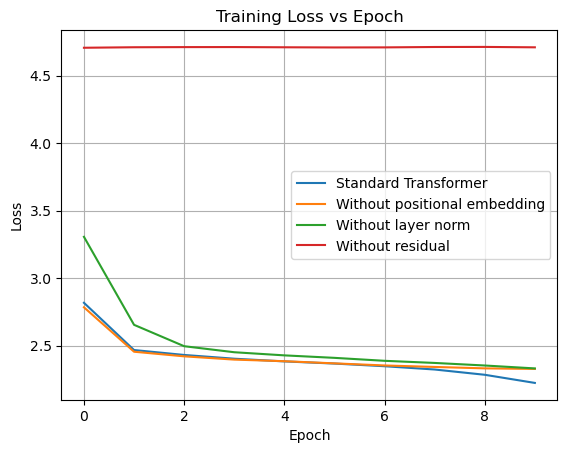

In [41]:
plt.plot(np.arange(epochs),standard_loss,label="Standard Transformer")
plt.plot(np.arange(epochs),no_pos_em_loss,label="Without positional embedding")
plt.plot(np.arange(epochs),no_ln_loss,label="Without layer norm")
plt.plot(np.arange(epochs),no_res_loss,label="Without residual")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss vs Epoch")
plt.grid(True)
plt.legend()
plt.savefig("positional_encoding_ablation.png",dpi=300,bbox_inches="tight")
plt.show()

In [42]:
test_ins,test_out=text_generate_batch(test_tokens,256,block_size)

In [45]:
standard_validation_loss=cross_entropy_loss(standard_transformer.forward_prop(test_ins),test_out)
no_posemb_validation_loss=cross_entropy_loss(no_pos_em.forward_prop(test_ins),test_out)
no_ln_validation_loss=cross_entropy_loss(no_ln.forward_prop(test_ins),test_out)
no_res_validation_loss=cross_entropy_loss(no_res.forward_prop(test_ins),test_out)
print("Standard transformer training and validation loss: ",standard_loss[-1],standard_validation_loss.data)
print("No position embedding transformer training and validation loss: ",no_pos_em_loss[-1],no_posemb_validation_loss.data)
print("No layer norm transformer training and validation loss: ",no_ln_loss[-1],no_ln_validation_loss.data)
print("No residual transformer training and validation loss: ",no_res_loss[-1],no_res_validation_loss.data)

Standard transformer training and validation loss:  2.2230811965622728 2.312680865182677
No position embedding transformer training and validation loss:  2.326764615886718 2.4390931695166786
No layer norm transformer training and validation loss:  2.330557308327058 2.4957795242746545
No residual transformer training and validation loss:  4.709637489003042 4.7002560680181755


In [46]:
iterations=1
prompt="Juliet! "

for i in range(iterations):
    print(generate_text(standard_transformer,prompt,encode_dict,decode_dict,500,block_size))

Juliet! sthak te we be Limb.
Ky My ORIN be A Muruthew pair of's mpeines
I amas t tannil bag Epaim?

NRIIf knt, ce polfars, avik mina min?

QUEEEEREN ETZABETH:
I leire t mone,
Whar ive a: thyour g-whalm,
And sthak se wit oreneartir f ale keie ar muce my nortest.

BENEN PY:
Yorait touth thand co toLe ow the treis op ait,. o pepow at whas, cakne chis, sllelghss ande

OUson uar sus hio uspelpst,
Tof yrnois, ds o adsiner marst gy hay tro wiou sbarse gHollorp 'ede,
Theoped ellow the,?

KINRG ICHEN IOze E drsh


In [47]:
iterations=1
prompt="Juliet! "

for i in range(iterations):
    print(generate_text(no_pos_em,prompt,encode_dict,decode_dict,500,block_size))

Juliet! aiO t ewnth s o, ut Y I be ta acouf tofl
'Gusutha thingoumel,
I ckindorthathind od h Grd in ay, buss or pu es,
Ofo I it heilaterofoll iver iciof by.
Thour hin f ce mand'sor:

Le Ro Cls, geangme thesheancotougansagld l,
Agaspanghioury burath
My ur y s t t;
Hol souar od ombend. RI a cthes?
TUCulofome whad f sotsar
The HADY:
Laberorsesesourvet Ron: a y th dar Calsurse ar oube d k, mbred thon odisthithefe,
Ang s ashim,
Oury llerom my wing hain.
GNCHES fan h k booree, San irvewiflly I de,
IC:

ARI m 


In [48]:
iterations=1
prompt="Juliet! "

for i in range(iterations):
    print(generate_text(no_ln,prompt,encode_dict,decode_dict,500,block_size))

Juliet! Dervime Vomy USIVII:

A:
La y, ieeourd y herd, ber hat orgug ar tag fave--

Angulapengofor'sct sly, andith tlfaven paiimingaitil-
I'
And; hind sty hers m! Ae ilirt ba don'lang I:


Whagat bls hanspe ee, bem, virtyatanit,
Ans kerat k an cathicof pin avenativent pald-menee veare.


GOFIUCHOTIUM:
Wh hft gne, ouveread inas me ban myooulan.

CIRIUSESSIAM:
To b.



DUCICICOFIUS:
In fount I pest ?



GLAMANGANIUS:
I ICalauiand t gio the:
Byorprodshintove a, y ale ouryorthan? antsf.



BUCHIDBREDIUCIOFK


In [49]:
iterations=1
prompt="Juliet! "

for i in range(iterations):
    print(generate_text(no_res,prompt,encode_dict,decode_dict,500,block_size))

Juliet! VPdgk?JK &pvAj?jIA?A&grcI-H?PmIF
IgYNQhCjYibIHYImhpxICqrTfP?hiEFINEXf&3I$Rm
x:Zj;nj'OIjH?3sp,jzj:I3HJrC iO?,cF;NNc,Id;I!jhkhLN'ycpIOBI' II3L
HPgjN3HN'B;3Z
?NijjCNAjrjjk,,ji3wZ33cpBh Zm3?LcEjHLnI3IZNzsIxEkivNm;yF??B
mj-q,
bjmmcIjimYc&fmJj3Ik-m;m$?h;ZL
IHHIjXihHLYc'Im?iip3LIB,?JjYicITHHpmizIiLL?s'C
;UjII,;lj3i?b,mk-BjpH3?TIIjc?,Dz',yiT-i?HNO3ybjqI;ZjLhHj?-dIHCfNjcMNI
PdN3'cWfjbzjppjIyOj
clBcRFh3Iji&zEjjcpbtzj-jbIZJ; ,,bIIi3:IcyicpNphHjfHIzH'BijJAjtNXjiH'MI!mjjhEIxzH',IjGHUXjjbR.Ni;R3DE'HjAHJL3cgMH
